In [1]:
# Khai báo Thư viện & Cấu hình
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from collections import Counter

# Cấu hình giao diện biểu đồ
%matplotlib inline
sns.set_theme(style="whitegrid")

In [2]:
# Nạp dữ liệu & Kỹ thuật đặc trưng
# 1. Nạp dữ liệu
try:
    df = pd.read_csv('dataset_01032026.csv')
    print(" Đã nạp file thành công!")
except FileNotFoundError:
    print(" Lỗi: Hãy kiểm tra file 'data_enrich.csv'.")
    raise

# 2. Tạo đặc trưng phái sinh
df['structure_density'] = df['num_siblings'] / (df['dom_depth'] + 1)
df['url_complexity'] = df['num_special_chars'] / (df['url_length'] + 1)

# Tiền xử lý Categorical
df_numeric = pd.get_dummies(df, columns=['request_type']) if 'request_type' in df.columns else df.copy()

# ÉP MODEL DÙNG DATA LÀM GIÀU (Xóa cột gây học vẹt)
cols_to_drop = ['is_ad', 'url', 'domain', 'target_url', 'dom_depth', 'num_siblings']
X = df_numeric.drop(columns=[col for col in cols_to_drop if col in df_numeric.columns])
y = df_numeric['is_ad']

 Đã nạp file thành công!


In [3]:
# Chia tập dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f" Dữ liệu tập Train: {Counter(y_train)}")

 Dữ liệu tập Train: Counter({0: 20237, 1: 3236})


 Đang chạy 5-Fold Cross-Validation...


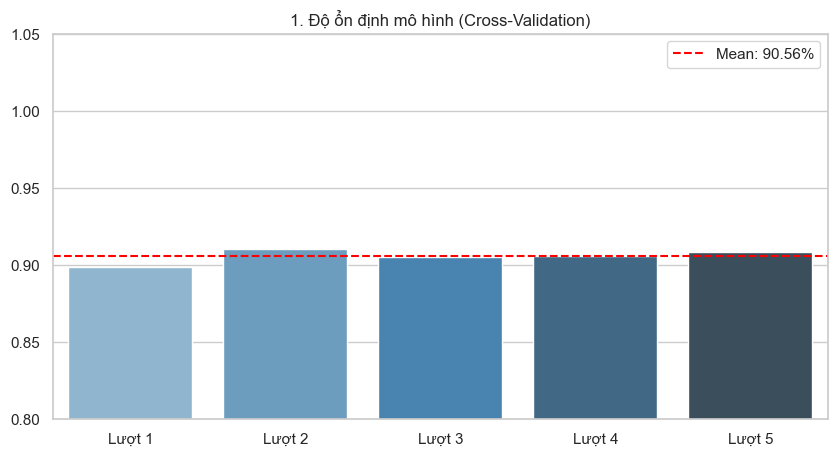

In [4]:
# Đánh giá độ ổn định (Cross-Validation)
# Khởi tạo model theo đúng Hyperparameters bạn đã chọn
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=15,
    max_features='log2', class_weight='balanced_subsample',
    random_state=42, n_jobs=-1
)

print(" Đang chạy 5-Fold Cross-Validation...")
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5)

# Trực quan hóa CV
plt.figure(figsize=(10, 5))
folds = [f"Lượt {i+1}" for i in range(len(cv_scores))]
sns.barplot(x=folds, y=cv_scores, hue=folds, palette="Blues_d", legend=False)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean()*100:.2f}%')
plt.title("1. Độ ổn định mô hình (Cross-Validation)")
plt.ylim(0.8, 1.05)
plt.legend()

# XUẤT ẢNH 1
plt.savefig('evaluation_cv_scores.png', dpi=300, bbox_inches='tight')
plt.show()

In [5]:
# Huấn luyện Mô hình
print("Đang huấn luyện mô hình chính...")
rf_model.fit(X_train, y_train)
print("Huấn luyện hoàn tất.")

Đang huấn luyện mô hình chính...
Huấn luyện hoàn tất.


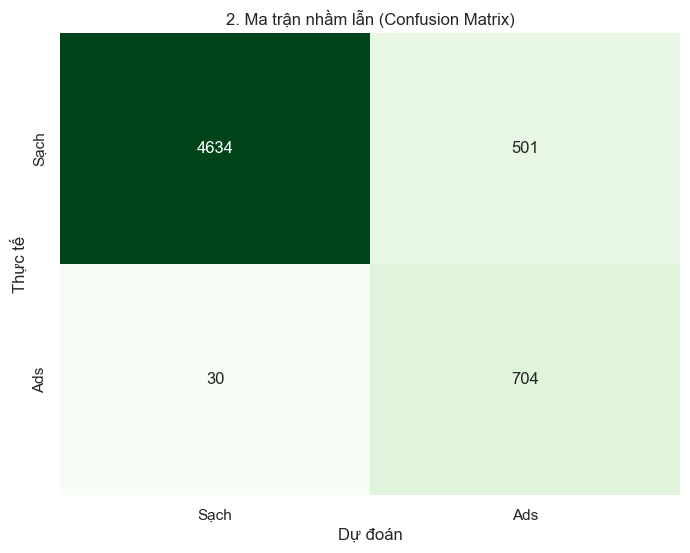


 ĐỘ CHÍNH XÁC THỰC TẾ: 0.909524620889419
              precision    recall  f1-score   support

           0       0.99      0.90      0.95      5135
           1       0.58      0.96      0.73       734

    accuracy                           0.91      5869
   macro avg       0.79      0.93      0.84      5869
weighted avg       0.94      0.91      0.92      5869



In [6]:
# Ma trận nhầm lẫn & Báo cáo chi tiết
y_pred = rf_model.predict(X_test)

# Vẽ Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Sạch', 'Ads'], yticklabels=['Sạch', 'Ads'], cbar=False)
plt.title("2. Ma trận nhầm lẫn (Confusion Matrix)")
plt.xlabel("Dự đoán")
plt.ylabel("Thực tế")

# XUẤT ẢNH 2
plt.savefig('evaluation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n ĐỘ CHÍNH XÁC THỰC TẾ:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

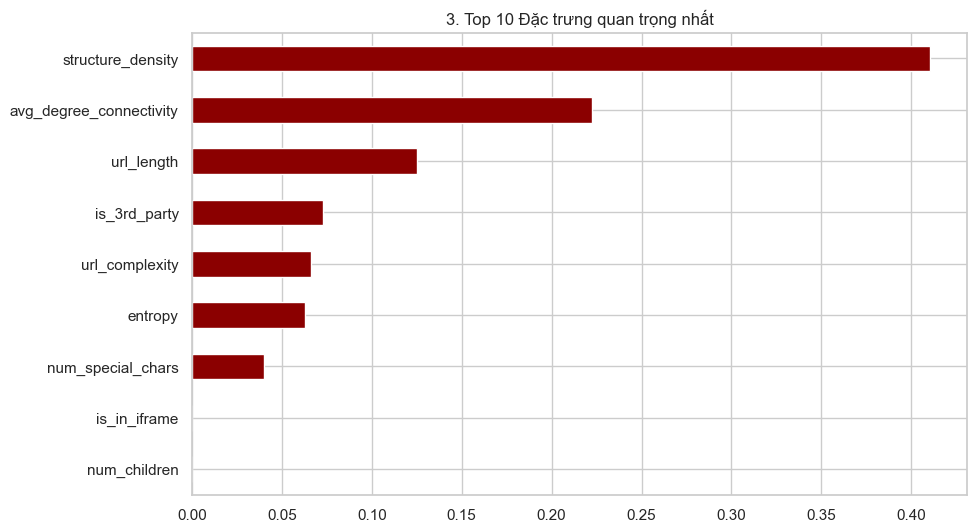


 Đã lưu model và danh sách feature!


In [7]:
# Đặc trưng quan trọng & Lưu trữ
# 1. Trực quan hóa Feature Importance
plt.figure(figsize=(10, 6))
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.nlargest(10).sort_values().plot(kind='barh', color='darkred')
plt.title("3. Top 10 Đặc trưng quan trọng nhất")

# XUẤT ẢNH 3
plt.savefig('evaluation_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Xuất file JOBLIB (Giữ nguyên cấu trúc storage của bạn)
storage = {'model': rf_model, 'features': X.columns.tolist()}
joblib.dump(storage, 'demo2.joblib')
print("\n Đã lưu model và danh sách feature!")